# Monte Carlo Methods

**Monte Carlo** methods require only *experience*--sample sequences of states, actions, and rewards from actual or simulated interaction with an environment. Learning from *actual* experience is striking because it requires no prior knowledge of the environment's dynamics, yet can still attain optimal behavior. Learning from *simulated* experience is also powerful.

Although a model is required, the model need only generate sample transitions, not the complete probability distributions of all possible transitions that is required for dynamic programing (DP). 

* Monte Carlo methods are ways of solving the reinforcement learning problem based on averaging sample returns
* Only on the completion of an episode are value estimates and policies changed. 
* Monte Carlo methods can be incremental in an episode-by-episode sense, but not in a step-by-step (online) sense

## Monte Carlo Prediction

Recall that the prediction problem means to learn the state-value function $v_{\pi}$ and the state-action pair $q_{\pi}$ for a given policy. The value of a state is the expected return-expected cumulative future discounted reward-starting from that state. A way to estimate it from experience is by averaging the returns observed after visits to that state. As more returns are observed, the average should converge to the expected value. This is the idea of all Monte Carlo methods.

Suppose we wish to estimate $v_{\pi}(s)$, the value of a state $s$ under policy $\pi$, given a set of episodes obtained by following $\pi$ and passing through $s$. Each occurrence os state $s$ in an episode is called a $visit$ to $s$. Clearly, $s$ may be visited multiple times in the same episode; let us call the first time it is visited in an episode the *first visit* to $s$. The *first-visit MC* method estimates $v_{\pi}$ as the average of returns following first visit to $s$, whereas the *every-visit MC* method averages the returns following all visits to $s$.

**First-visit MC prediction for estimating $V \approx v_{\pi}$**

The pseudocode for this algorithm is the following:

```text
Input: a policy pi to be evaluated
Initialize:
    V(s) -> float, arbitrarily, for all states
    Returns(s) -> [], for all states

Loop forever(for each episode):
    Generate an episode following pi: s0, a0, r1, s1, a1, r2, ..., s{T-1}, a{T-1}, r{T}
    G = 0
    Loop for each step of episode, t=T-1, T-2, ..., 0
        G = gamma*G + r[t+1]
        Unless s[t] appears in s0, s1, ..., s{t-1}:
            Returns(s[t]).append(G)
            V(s[t]) = mean(Returns(s[t]))

Both *first-visit* MC and *every-visit* MC converge to $v_{\pi}(s)$ as the number of visits (or first visits) to $s$ goes to infinity.

### Example: BlackJack

First, we import the libraries:

In [2]:
import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import random

from collections import defaultdict
from tqdm import tqdm

We will create some useful functions to plot our results:

Function to Plot v_s Values

In [3]:
def plot_blackjack_values(V_s):

    def get_Z(x, y, usable_ace):
        if (x, y, usable_ace) in V_s:
            return V_s[x, y, usable_ace]
        else:
            return 0
        
    def get_figure(usable_ace, ax):
        x_range = np.arange(12, 22)
        y_range = np.arange(1, 11)
        X, Y = np.meshgrid(x_range, y_range)

        Z = np.array([get_Z(x, y, usable_ace) for x, y in zip(np.ravel(X), np.ravel(Y))]).reshape(X.shape)

        surface = ax.plot_surface(X, Y, Z, rstride=1, cstride=1, cmap=plt.cm.coolwarm, vmin=-1.0, vmax=1.0)
        ax.set_xlabel('Player\'s Sum')
        ax.set_ylabel('Dealer\'s Showing Card')
        ax.set_zlabel('State Value')
        ax.view_init(ax.elev, -120)
        
    fig = plt.figure(figsize=(20, 20))
    ax = fig.add_subplot(211, projection='3d')
    ax.set_title('Usable Ace')
    get_figure(True, ax)
    ax = fig.add_subplot(212, projection='3d')
    ax.set_title('No Usable Ace')
    get_figure(False, ax)
    plt.show()

Function to plot the policy

In [4]:
def plot_blackjack_policy(policy):
    player_range = np.arange(11, 22)
    dealer_range = np.arange(1, 11)
    
    def get_grid(usable_ace):
        grid = np.zeros((len(player_range), len(dealer_range)))
        for i, p in enumerate(player_range):
            for j, d in enumerate(dealer_range):
                grid[i, j] = policy[(p, d, usable_ace)]
        return grid

    fig, ax = plt.subplots(1, 2, figsize=(15, 6))

    # Plot avec As utilisable
    sns.heatmap(get_grid(True), xticklabels=dealer_range, yticklabels=player_range, 
                cmap="YlGnBu", annot=True, cbar=False, ax=ax[0])
    ax[0].set_title('Usable Ace')
    ax[0].invert_yaxis()

    # Plot sans As utilisable
    sns.heatmap(get_grid(False), xticklabels=dealer_range, yticklabels=player_range, 
                cmap="YlGnBu", annot=True, cbar=False, ax=ax[1])
    ax[1].set_title('No Usable Ace')
    ax[1].invert_yaxis()

    for a in ax:
        a.set_xlabel('Dealer\'s hand')
        a.set_ylabel('Player\'s Sum')
    
    plt.show()

We will use gymnasium library and their implementation of this environment.

In [5]:
env = gym.make('Blackjack-v1', sab=True) # Following rules of sutton and barto

We can check the observation space of this environment:

In [6]:
env.observation_space

Tuple(Discrete(32), Discrete(11), Discrete(2))

This is because each observation is a tuple of three values. The first one is the sum of the player. The second value is the value the dealer is showing and the third one if the player has usable aces, 0 if it doesn't have and 1 otherwise.

In the same way, we can see the action space:

In [7]:
env.action_space

Discrete(2)

Two possible actions: either hit or stick. 0 in the case it sticks and 1 if it hits

The *first visit* MC in code can be seen below:

In [8]:
def first_visit_mc(policy, env, gamma = 1, episodes=200):
    v_s = defaultdict(lambda: 0)
    n_s = defaultdict(lambda: 0)

    for _ in range(episodes):
        
        obs, info = env.reset()
        done = False

        states = []
        rewards = []

        # Play episode
        while not done:
            action = policy(obs)
            next_obs, reward, terminated, truncated, info = env.step(action)

            states.append(obs)
            rewards.append(reward)

            done = terminated or truncated
            obs = next_obs

        G = 0
        for t in range(len(states)-1, 0, -1):
            G = gamma*G + rewards[t]
            if states[t] not in states[:t]:
                n_s[states[t]] += 1
                v_s[states[t]] += (G - v_s[states[t]]) / n_s[states[t]]
        
    return v_s

We can call the function using as policy the one described in the problem:

In [9]:
def player_policy(obs):
    if obs[0] >= 20: # If user sum is 20 or 21 sticks, hit otherwise
        return 0
    return 1

env = gym.make('Blackjack-v1', sab=True) # Following rules of sutton and barto
v_s = first_visit_mc(player_policy, env, gamma=1, episodes=10000)

Then, we can plot the state value function. We will use a function as auxiliar for doing so.

In [10]:
env.observation_space

Tuple(Discrete(32), Discrete(11), Discrete(2))

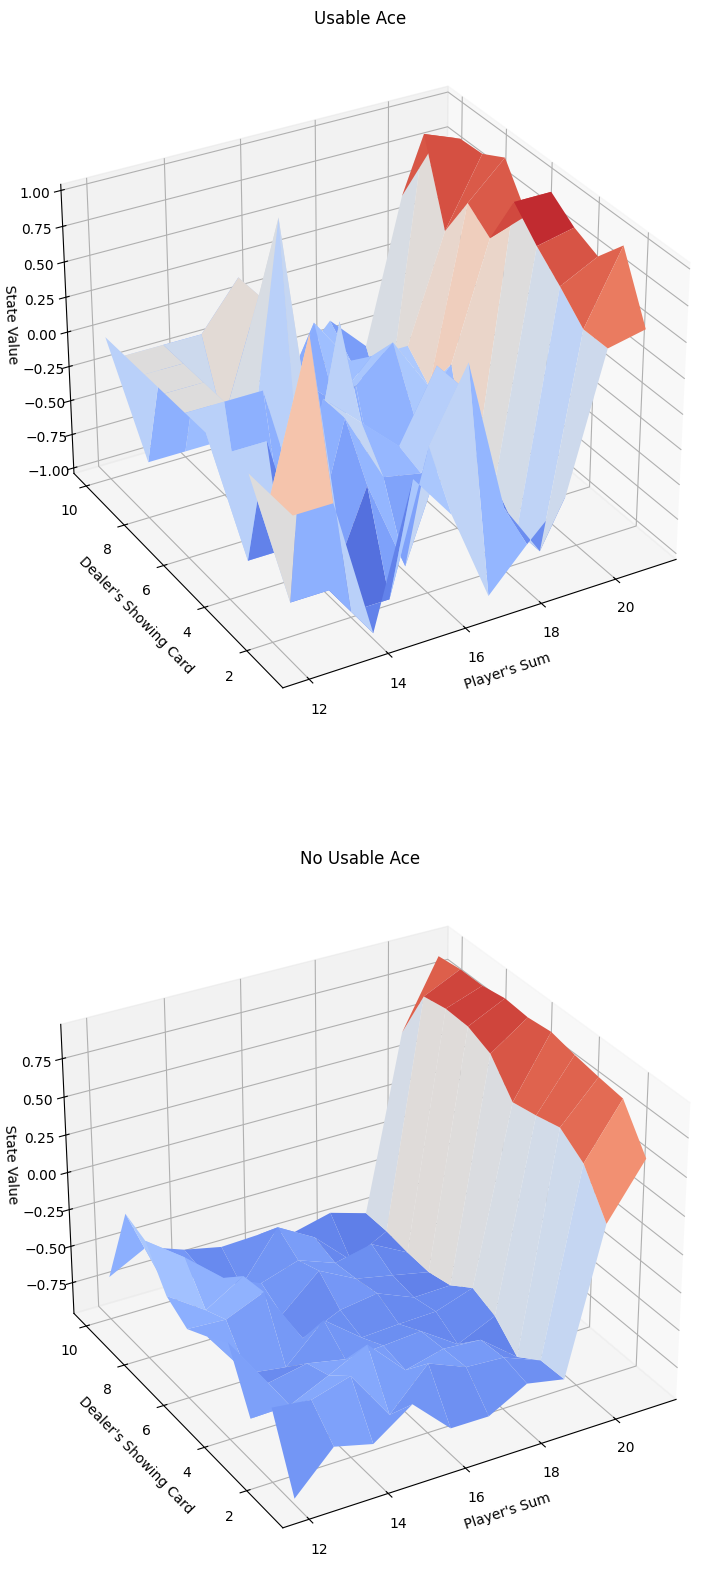

In [11]:
plot_blackjack_values(v_s)

Although we have complete knowledge of the environment in the blackjack task, it would not be easy to apply DP methods to compute the value function. DP methods require the distribution of next events-in particular, they require the environments dynamics as given by the four-argument function $p$, and it is not easy to determine this for blackjack.

## Monte Carlo Estimation of Action Values

If a model is not available, then it is particularly useful to estimate *action* values (the values of state-action pairs) rather than *state* values. Without a model, however, state values alone are not sufficient. One must explicitly estimate the value of each action in order for the values to be useful in suggesting a policy. Thus, one of our primary goals for Monte Carlo methos is to estimate $q_{*}$. To achieve this, we first consider the policy evalution problem for action values.

The Monte Carlo methos for this are essentially the same as just presented for state values, except now we talk about visits to a state-action pair rather than to a state. A state-action pair $s,a$ is said to be visited in an episode if ever the state $s$ is visited and action $a$ is taken in it. The every-visit MC method estimates the value of a state-action pair as the average of the returns that have followed all the visits ot it. The first-visit MC method averages the returns following the first time in each episode that the state was visited around and the action was selected.

The only complication is that many state-action pairs may never be visited. If $\pi$ is a deterministic policy, then in following $\pi$ one will observe returns only for one of the actions from each state. With no returns to average, the Monte Carlo estimates of the other actions will not improve with experience. To compare alternatives we need to estimate the values of all the actions from each state, not just the one we currently favor. 

One way to do this is by specifying that the episodes start in a state-action pair, and that every pair has nonzero probability of being selected as the start. This guarantees that all state-action pairs will be visited an infinite number of times in the limit of an infinite number of episodes. We call this the assumption of exploring starts.

## Monte Carlo Control

In GPI (generalized policy iteration), one maintains both an approximate policy and an approximate value function. The value function is repeatedly altered to more closely approximate the value function for the current policy, and the policy is repeatedly improved with respect to the current value function.

For Monte Carlo, many episodes are experienced, with the approximate action-value function approaching the true function asymptotically. Policy improvement is done by making the policy greedy with respect to the current value function. In this case we have an action-value function, and therefore no model is needed to cnostruct the greedy policy. For any action-value function $q$, the corresponding greedy policy is the one that, for each $s \in \mathcal{S}$, deterministically chooses an action with maximal action-value:

$$
\pi(s) = \operatorname*{argmax}_a q(s, a)
$$

For Monte Carlo policy iteration it is natural to alternate between evaluation and improvement on an episode-by-episode basis. After each episode, the observed returns are used for policy evaluation, and then the policy is improved at all the states visited in the episode. 

The following is a simple algorithm that implements Monte Carlo control called *Monte Carlo ES*, for *Monte Carlo with Exploring Starts*.

**Monte Carlo ES (Exploring Starts), for estimating $\pi \approx \pi_*$**

```text
Initialize:
    pi(s) -> A(s), for all states
    Q(s, a) -> float, for all states s and all actions in that state
    Returns(s, a) -> [], for all states and all actions in that state

Loop forever(for each episode):
    Choose s0 from S and a0 from A(s0) randomly such that all pairs have probability > 0
    Generate an episode from s0, a0, following pi: s0, a0, r1, s1, a1, r2, ..., s{T-1}, a{T-1}, r{T}
    G = 0
    Loop for each step of episode, t=T-1, T-2, ..., 0
        G = gamma*G + r[t+1]
        Unless the pair s[t], a[t] appears in s0, a0, s1, a1, ..., s{t-1}, a{t-1}
            Returns(s[t], a[t]).append(G)
            Q(s[t], a[t]) = mean(Returns(s[t], a[t]))
            pi(s[t]) = argmax_a Q(s[t], a)

### Example: Solving Blackjack

In [12]:
def monte_carlo_es(env, gamma = 1, episodes=200):
    pi = defaultdict(lambda: 0) # Values will be either 0 or 1 (the actions)
    q = defaultdict(lambda: np.zeros(env.action_space.n))
    n_s = defaultdict(lambda: 0)

    for _ in tqdm(range(episodes)):
        
        obs, info = env.reset() # Gives a random state
        action = env.action_space.sample()
        done = False

        episode = []

        # Play episode
        while not done:
            next_obs, reward, terminated, truncated, info = env.step(action)

            episode.append((obs, action, reward))

            done = terminated or truncated
            obs = next_obs
            action = pi[obs]
            
        G = 0
        visited_state_action = set()
        for t in range(len(episode)-1, -1, -1):
            s_t, a_t, r_t = episode[t]
            G = gamma*G + r_t
            if (s_t, a_t) not in visited_state_action:
                visited_state_action.add((s_t, a_t))
                n_s[s_t] += 1
                q[s_t][a_t] += (G - q[s_t][a_t]) / n_s[s_t]
                pi[s_t] = np.argmax(q[s_t])
        
    return (pi, q)

In [13]:
pi, q = monte_carlo_es(env, 1, 5_000_000)

100%|██████████| 5000000/5000000 [02:47<00:00, 29936.65it/s]


In [14]:
v_s = defaultdict(lambda: 0)
for state, actions in q.items():
    v_s[state] = actions[pi[state]]

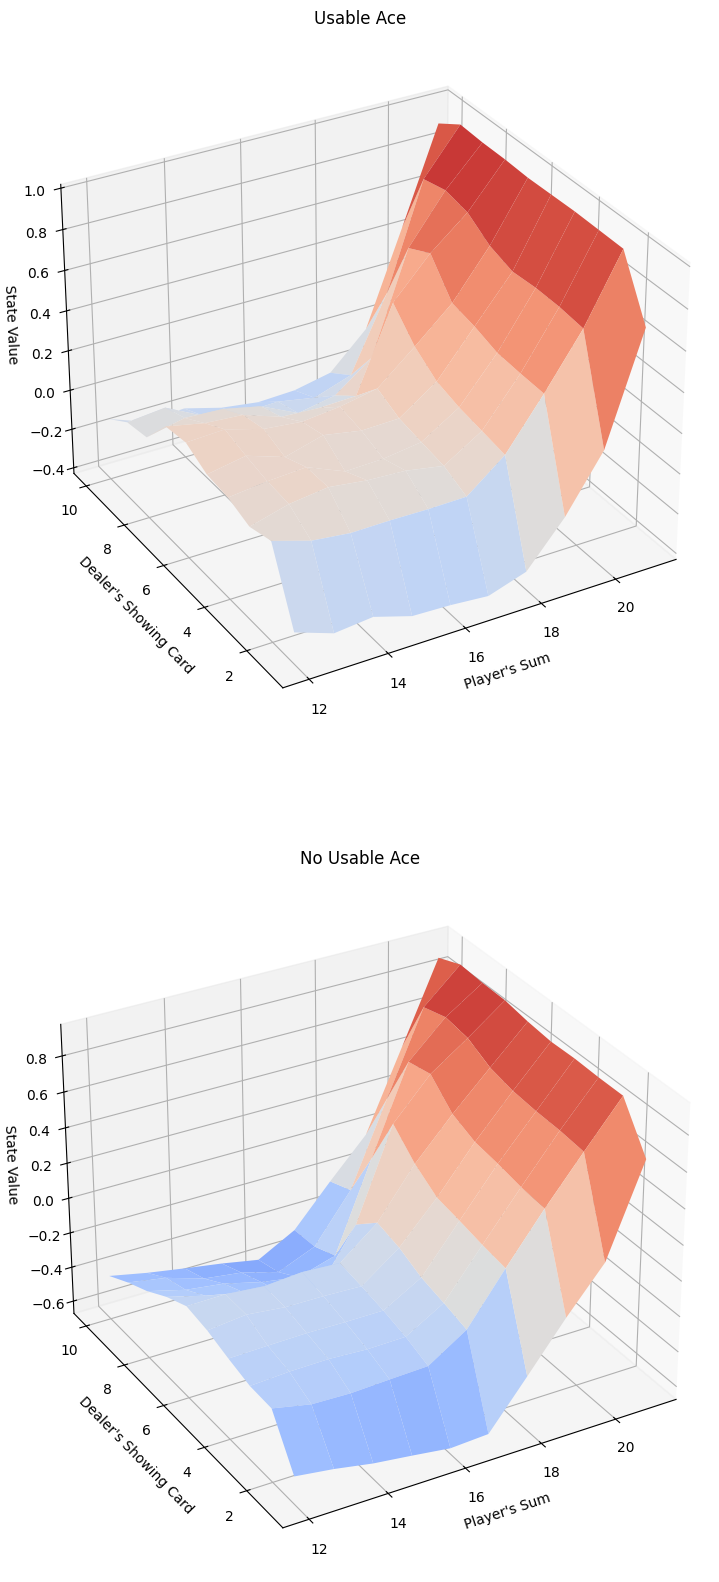

In [15]:
plot_blackjack_values(v_s)

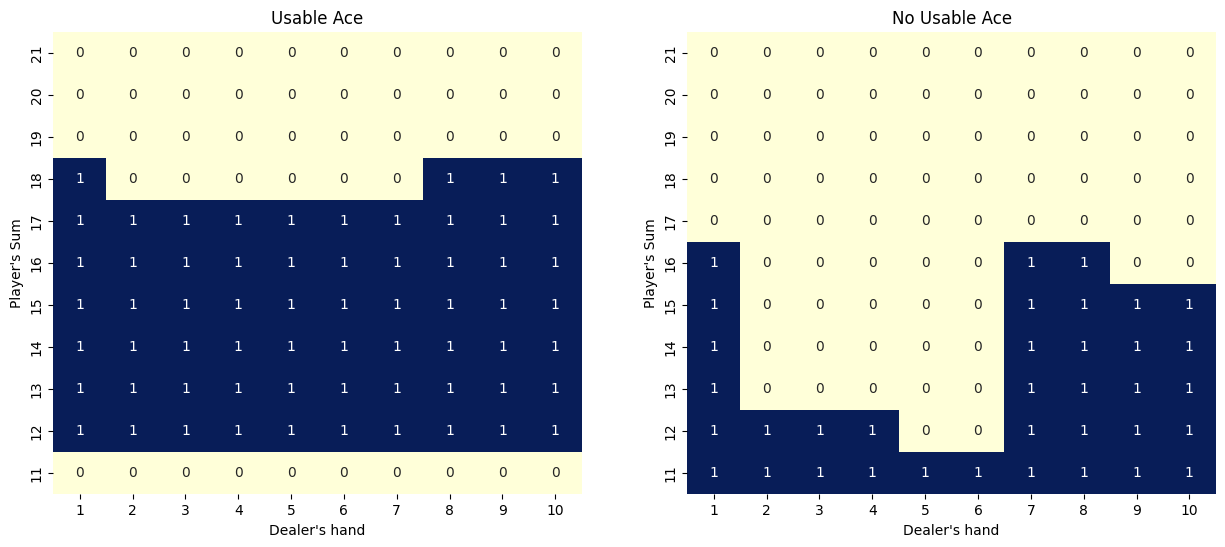

In [16]:
plot_blackjack_policy(pi)

As we can see Usable Ace always sticks for player's sum = 11. This happens because the agent never enters to this state, it is impossible to have as player sum 11 with an usable ace, since the only way to have it is 11 + 0 which is imposible.  Any other combination either surpass that value (5 + 6 + ace) or the ace it is used to form a bigger number (ace + 10), ace will be used to form 21. 

## Monte Carlo Control without Exploring Starts

How to avoid the assumption of exploring starts? The only general way to ensure that all actions are selected infinitely often is for the agent to continue to select them. The are two approaches to ensuring this:

* **On-Policy** methods
* **Off-Policy** methods

**On-Policy** methods attempt to evaluate or improve the policy that is used to make decisions, whereas **Off-policy** methods methods evaluate or improve a policy different from that used to generate the data. The Monte Carlo ES method developed. above is an example of an on-policy method.

In **on-policy** control methods the policy is generally *soft*, meaning that $\pi(a|s) > 0$ for all $s \in \mathcal{S}$ and all $a \in \mathcal{A}$, but gradually shifted closer and closer to a deterministic optimal policy.

The **on-policy** method presented uses $\epsilon$-*greedy* policies, meaning that most of the time they choose an action that has maximal estimated action value, but with probability $\epsilon$ they intsead select an action at random. 

**On-Policy first-visit MC control (for $\epsilon$-soft policies), estimates $\pi\approx \pi_*$**

```text
Algorithm parameter: small eps > 0
Initialize:
    pi -> an arbitrary eps-soft policy
    Q(s, a) -> float, for all states s and all actions in that state
    Returns(s, a) -> [], for all states and all actions in that state

Loop forever(for each episode):
    Generate an episode following pi: s0, a0, r1, ..., s_{T-1}, a_{T-1}, R{T}
    G = 0
    Loop for each step of episode, t=T-1, T-2, ..., 0
        G = gamma*G + r[t+1]
        Unless the pair s[t], a[t] appears in s0, a0, s1, a1, ..., s{t-1}, a{t-1}
            Returns(s[t], a[t]).append(G)
            Q(s[t], a[t]) = mean(Returns(s[t], a[t]))
            A* = argmax_a Q(s[t], a)
            For all a in A[S[t]]:
                pi(a|s[t]) = 1 - eps + eps/|A(s[t])| if a = A* ? eps/|A(s[t]) if a != A*

## Off-policy Prediction via Importance Sampling

How can a control method learn about the optimal policy while behaving according to an exploratory policy? The on-policy approach in the preceding section is actually a compromise-it learns action values not for the optimal policy, but for a near-optimal policy that still explores. A more straightforward approach is to use two policies, one that is learned about and that becomes the optimal policy, and one that is more exploratory and is used to generate behavior. The policy being learned about is called the **target policy**, and the policy used to generate behavior is called the **behavior policy**. In this case we say that learning is from data "off" the target policy, and the overal process is termed *off-policy learning*.

### Prediction Problem

Consider the *prediction* problem, in which both target and behavior policies are fixed. That is, suppose we wish to estimate $v_{\pi}$ or $q_{\pi}$, but all we have are episodes following another policy $b$, where $b \neq \pi$. In this case, $\pi$ is the target policy, $b$ is the behavior policy, and both policies are considered fixed and given.

In order to use episodes from $b$ to estimate values for $\pi$, we require that every action taken under $\pi$ is also taken, at least occasionally, under $b$. That is, we require that $\pi(a|s) > 0$ implies $b(a|s) > 0$. This is called the assumption of *coverage*. It follows from coverage that $b$ must be stochastic in states where it is not idential to $\pi$. The target policy $\pi$, on the other hand, may be deterministic, and, in fact, this. is a case of particular interest in control applications. In control, the target policy is typically the deterministic greedy policy with respect to the current estimate of the action-value function. This policy becomes a deterministic optimal policy while the behavior policy remains stochastic and mroe exploratory, for example, an $\epsilon$-greedy policy.

Almost all off-policy methods utilize *importance sampling*, a general technique for estimating expected values under one distribution given samples from another. We apply importance sampling to off-policy learning by weighting returns according to the relative probability of their trajectories occurring under the taret and behavior policies, called the *importance-sampling ration*. Given a starting state $S_t$, the probability of the subsequent state-action trajectory, $A_t, S_{t+1},A_{t+1},...,S_{T}$, occurring under any policy $\pi$ is:

$$
Pr{A_t, S_{t+1},A_{t+1},...,S_{T}|S_t,A_{t:T-1} \sim \pi} = \pi(A_t,S_t)p(S_{t+1}|S_t, A_t)\pi(A_{t+1}|S_{t+1})...p(S_T|S_{T-1},A_{T-1})
$$
$$
=\prod_{k=t}^{T-1} \pi(A_k|S_k)p(S_{k+1}|S_k,A_k)
$$

where $p$ here is the state-transition probability function. Thus, the relative probability of the trajectory under the target and behavior policies (the importance sampling ration) is:

$$
p_{t:T-1} = \frac{\prod_{k=t}^{T-1}\pi(A_k|S_k)p(S_{k+1}|S_k, A_k)}{\prod_{k=t}^{T-1}b(A_k|S_k)p(S_{k+1}|S_k, A_k)} = \prod_{k=t}^{T-1} \frac{\pi(A_k|S_k)}{b(A_k|S_k)}
$$

Recall that we wish to estimate the expect5ed returns (values) under the target policy, but all we have are returns $G_t$ due to the behavior policy. These returns have the wrong expectation $\mathbb{E}[G_t|S_t=s] = v_b(s)$ and so cannot be averaged to obtain $v_{\pi}$. This is where importance sampling comes in. The ration $p_{t:T-1}$ transforms the returns to have the right expected value:

$$
\mathbb{E}[p_{t:T-1}G_t|S_t = s] = v_{\pi}(s)
$$

It is convenient 

## Incremental Implementation

Monte Carlo prediction methods can be implemented incrementally, on an episode-by-episode basis. For *off-policy* Monte Carlo methods, we need to separately consider those that use *ordinary importance sampling* and those that use *weighted importance sampling*.

In ordinary importance sampling, the returns are scaled by the importance sampling ration $p_{t:T(t)-1}$, then simply averaged. For these methods we can again use the incremental methods of Chapter 2, but using the scaled returns in place of the rewards of that chapter. 

For the case of *off-policy* methods using *weighted importance sampling*, we have to form a weighted average of the returns, and a slightly different incremental algorithm is required.

Suppose we have a sequence of returns $G_1, G_2, ..., G_{n-1}$, all starting in the same state and each with a corresponding random weight $W_i$ (e.g., $W_i = p_{t_i:T(t_i)-1}$). We wish to form the estimate:

$$
V_n =\dot{=} \frac{\sum_{k=1}^{n-1}W_k G_k}{\sum_{k=1}^{n-1}W_k},  n \geq 2
$$

and keep it up-to-date as we obtain a single additional return $G_n$. In addition to keeping atrack of $V_n$, we must maintain for each state the cumulative sum $C_n$ of the weights given to the first $n$ returns. The update rule for $V_n$ is:

$$
V_{n+1} \dot{=} V_n + \frac{W_n}{C_n} \left[ G_n - V_n \right], n \geq 1
$$

and

$$
C_{n+1} \dot{=} C_n + W_{n+1}
$$

where $C_0 \dot{=} 0$ (and $V_1$ is arbitrary aand thus need not be specified).

**Off-policy MC prediction (policy evaluation) for estimating $Q \approx q_{\pi}$**

```text
Input: an arbitrary target policy pi
Initialize, for all states s and all actions in each state
    Q(s, a) -> float, arbitrarily
    C(s, a) -> 0

Loop forever(for each episode):
    b <- any policy with coverage of pi
    Generate an episode following b: s0, a0, r1, ..., s_{T-1}, a_{T-1}, R{T}
    G = 0
    W = 1
    Loop for each step of episode, t=T-1, T-2, ..., 0, while W not 0:
        G = gamma*G + r[t+1]
        C(s[t], a[t]) = C(s[t], a[t]) + W
        Q(s[t], a[t]) = Q(s[t], a[t]) + (W/C(s[t], a[t]))*(G - Q(s[t], a[t]))
        W = W*(pi(a[t]|s[t])/b(a[t]|s[t]))

## Off-policy Monte Carlo Control

There are two policies: target and behavior. An advantage of this separation is that the target policy may be deterministic (e.g., greedy), while the behavior policy can continue to sample all possible actions. These techniques require that the behavior policy has a nonzero probability of selecting all actions that might be selected by the target policy (coverage). To explore all possibilities, we require that the behavior policy be soft(i.e., that it select all actions in all states with nonzero probability).

**Off-policy MC control, for estimating $\pi \approx \pi_*$**

```text
Initialize, for all states s and all actions in each state
    Q(s, a) <- float, arbitrarily
    C(s, a) <- 0
    pi(s) <- argmax_a Q(s, a) (with ties broken consistently)

Loop forever(for each episode):
    b <- any soft policy
    Generate an episode following b: s0, a0, r1, ..., s_{T-1}, a_{T-1}, R{T}
    G = 0
    W = 1
    Loop for each step of episode, t=T-1, T-2, ..., 0, while W not 0:
        G = gamma*G + r[t+1]
        C(s[t], a[t]) = C(s[t], a[t]) + W
        Q(s[t], a[t]) = Q(s[t], a[t]) + (W/C(s[t], a[t]))*(G - Q(s[t], a[t]))
        pi(s[t]) = argmax_a Q(s[t], a) (with ties broken consistently)
        If a[t] not pi(s[t]) then exit inner loop (proceed to next episode)
        W = W*(1/b(a[t]|s[t]))

Above pseudocode has an off-policy Monte Carlo control method, based on GPI and weighted importance sampling, for estimating $\pi_*$ and $q_*$. The target policy $\pi \approx \pi_*$ is the greedy policy with respect to $Q$, which is an estimate of $q_{\pi}$. The behavior policy can be anything, but in order to assure convergence of $\pi$ to the optimal policy, an infinite number of returns must be obtained for each pair of state and action. This can be assured by choosing $b$ to be $\epsilon$-soft.

A potential problem is that this method learns only from the tails of episodes, when all of the remaining actions in the episode are greedy. If nongreedy actions are common, then learning will be slow, particularly for states appearing in the early portions of long episodes.

## Example with racetrack

In [17]:
import gymnasium as gym
import skimage.draw
import numpy as np
import numpy.ma as ma

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches

from IPython import display

class RacetrackEnv(gym.Env):
    """ Racetrack environment
        This custom environment is taken from: https://github.com/vojtamolda/reinforcement-learning-an-introduction/blob/main/chapter05/racetrack.py
    """
    max_accel = 1
    max_speed = 5
    grass, road, start, finish = 0, 1, 2, 3

    action_space = gym.spaces.MultiDiscrete([2 * max_accel + 1, 2 * max_accel + 1])
    reward_range = (-1, 1)

    def __init__(self, racetrack_txt, noisy=True):
        self.racetrack = np.flipud(np.genfromtxt(racetrack_txt, delimiter=1, dtype=int))
        self.observation_space = gym.spaces.MultiDiscrete([*self.racetrack.shape, self.max_speed, self.max_speed])
        self.state = None

        self.noisy = noisy
        self.ax = None
        self.fig = None

    def step(self, action):
        position, speed = np.hsplit(self.state, 2)

        if self.noisy and np.random.rand() < 0.1:
            acceleration = np.array([0, 0])
        else:
            acceleration = action
        
        speed += acceleration

        speed = np.clip(speed, 0, self.max_speed)
        starts = np.where(self.racetrack == self.start)
        if tuple(position) not in zip(*starts):
            speed = speed if (speed > 0).any() else np.array([0,1])

        position += speed

        row_s, col_s = skimage.draw.line(*(position - speed), *position)
        row_s_within_track = np.clip(row_s, 0, self.racetrack.shape[0] - 1)
        col_s_withing_track = np.clip(col_s, 0, self.racetrack.shape[1] - 1)
        collisions = self.racetrack[row_s_within_track, col_s_withing_track]

        on_road = (row_s == row_s_within_track).all() and (col_s == col_s_withing_track).all()
        crossing_goal = (collisions == self.finish).any()
        on_grass = (collisions == self.grass).any()

        # Restart when on grass or going out of racetrack limits without crossing finish line
        if on_grass or (not on_road and not crossing_goal):
            # self.render()
            self.reset()
            return self.state, -1.0, False, {}
        
        # Clip position to racetrack limits (applies when crossing the finish line)
        clipped = np.clip(position, 0, np.array(self.racetrack.shape)-1)
        speed -= position - clipped
        position = clipped

        self.state = np.hstack((position, speed))
        if crossing_goal:
            reward = -1.0
        else:
            reward = -1.0
            
        return self.state, reward, crossing_goal, {}

    def reset(self, state=None, hard=True):
        if self.ax is not None:
            self.ax.clear()
            
        if state is None:
            starts = np.where(self.racetrack == self.start)
            idx = np.random.randint(starts[0].size)
            position = np.array([starts[0][idx], starts[1][idx]])
            speed = np.array([0, 0])

            self.state = np.hstack((position, speed))
        else:
            self.state = state

        return self.state

    def render(self, mode='human'):
        if self.ax is None:
            self.fig, self.ax = plt.subplots()

        # Racetrack background
        cmap = mcolors.ListedColormap(['white', 'gray', 'red', 'green'])

        self.ax.pcolormesh(self.racetrack, edgecolors='black', cmap=cmap, linewidth=0.5)
        self.ax.set_aspect('equal')
        
        position, speed = np.hsplit(self.state, 2)

        x = position[1]
        y = position[0]
        dx = speed[1]
        dy = speed[0]

        position = np.array([x, y])
        speed = np.array([dx, dy])

        if (speed == 0).all():
            patch = mpatches.Circle(position, radius=0.1, color='black', zorder=1)
        else:
            patch = mpatches.FancyArrow(*(position - speed), *speed, color='black', zorder=2, fill=True, width=0.05, head_width=0.5)

        self.ax.add_patch(patch)
        print('Before printing')
        display.display(self.fig)

```text
Algorithm parameter: small eps > 0
Initialize:
    pi -> an arbitrary eps-soft policy
    Q(s, a) -> float, for all states s and all actions in that state
    Returns(s, a) -> [], for all states and all actions in that state

Loop forever(for each episode):
    Generate an episode following pi: s0, a0, r1, ..., s_{T-1}, a_{T-1}, R{T}
    G = 0
    Loop for each step of episode, t=T-1, T-2, ..., 0
        G = gamma*G + r[t+1]
        Unless the pair s[t], a[t] appears in s0, a0, s1, a1, ..., s{t-1}, a{t-1}
            Returns(s[t], a[t]).append(G)
            Q(s[t], a[t]) = mean(Returns(s[t], a[t]))
            A* = argmax_a Q(s[t], a)
            For all a in A[S[t]]:
                pi(a|s[t]) = 1 - eps + eps/|A(s[t])| if a = A* ? eps/|A(s[t]) if a != A*

In [18]:
def sample_episode(env, pi, deterministic=False, render=False, max_steps=20):
    """ Follows an eps-soft policy through an episode and return array of actions, states and returns"""
    choices_idxs = np.arange(int(np.prod(env.action_space.nvec)))

    done = False
    obs = env.reset()
    if render:
        env.render()

    episode = []

    step = 0
    while not done and step < max_steps:
        # Transform obs to tuple since dictionaries cannot use np arrays are key
        obs = tuple(obs.tolist())

        action_idx = np.random.choice(choices_idxs, p = pi[obs].flatten())
        action = np.array(np.unravel_index(action_idx, env.action_space.nvec))
        next_obs, reward, done, info = env.step(action-1)

        episode.append((obs, action, reward))

        obs = next_obs

        if render:
            env.render()

        if deterministic:
            step+=1

    plt.close()
    return episode

In [19]:
def on_policy_mc_control_eps_soft(env, gamma=0.05, eps=0.1, n_episodes=3):
    """Finds a deterministic policy and the q table"""

    n_actions = np.prod(env.action_space.nvec)

    pi = defaultdict(lambda: np.ones(env.action_space.nvec)/n_actions)
    q = defaultdict(lambda: np.zeros(env.action_space.nvec)) 
    n_s = defaultdict(lambda: np.zeros(env.action_space.nvec))

    for _ in tqdm(range(n_episodes)):
        episode = sample_episode(env, pi)

        G = 0
        visited_state_action = set()
        for t in range(len(episode)-1, -1, -1):
            s_t, a_t, r_t = episode[t]
            state_action_t = s_t + tuple(a_t.tolist())

            G = gamma*G + r_t
            if state_action_t not in visited_state_action:
                visited_state_action.add(state_action_t)
                n_s[s_t][a_t] += 1
                q[s_t][a_t] += (G - q[s_t][a_t]) / n_s[s_t][a_t]

                flat_idx = np.argmax(q[s_t] + np.random.randn(*q[s_t].shape) * 1e-10)
                idx1, idx2 = np.array(np.unravel_index(flat_idx, q[s_t].shape))

                pi[s_t][ :, :] = eps / n_actions
                pi[s_t][idx1, idx2] = 1 - eps + eps/n_actions
    
    # Transform to greedy policy
    pi_greedy = defaultdict(lambda: np.zeros(env.action_space.nvec))
    for key, value in pi.items():
        max_id = np.argmax(value)
        idx1, idx2 = np.unravel_index(max_id, env.action_space.nvec)
        pi_greedy[key] = np.zeros(env.action_space.nvec)
        pi_greedy[key][idx1, idx2] = 1

    return (pi, pi_greedy, q)

In [20]:
env = RacetrackEnv('racetrack_test.txt', noisy=False)
pi_eps_soft, pi, q = on_policy_mc_control_eps_soft(env, gamma=0.9, n_episodes=5_000)

100%|██████████| 5000/5000 [00:03<00:00, 1644.53it/s]


Before printing


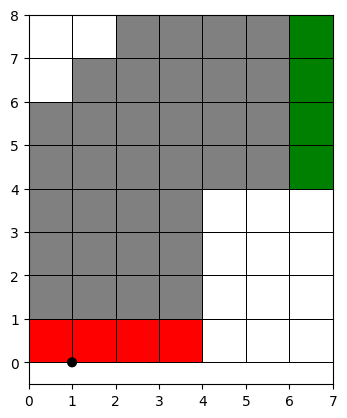

Before printing


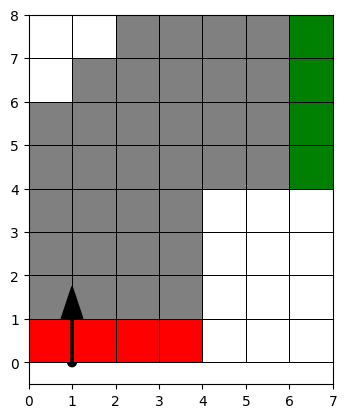

Before printing


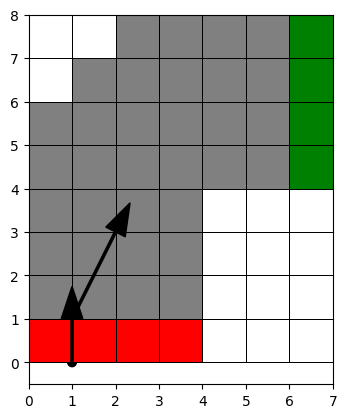

Before printing


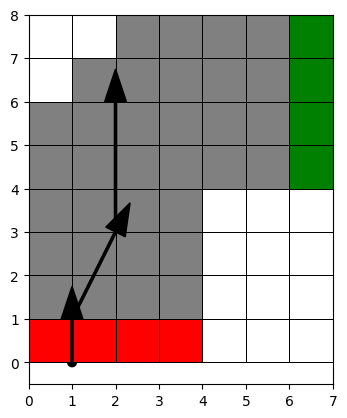

Before printing


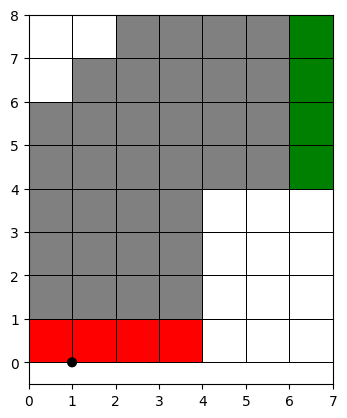

Before printing


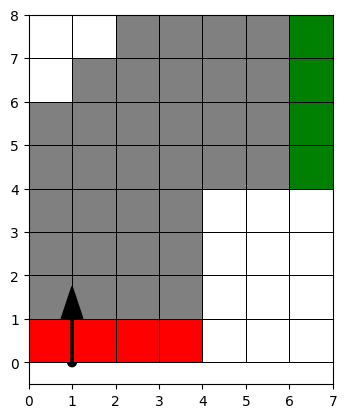

Before printing


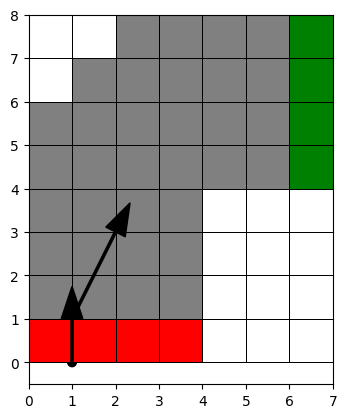

Before printing


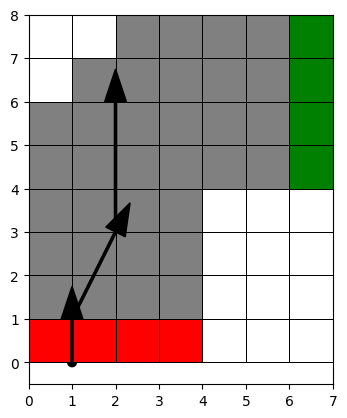

Before printing


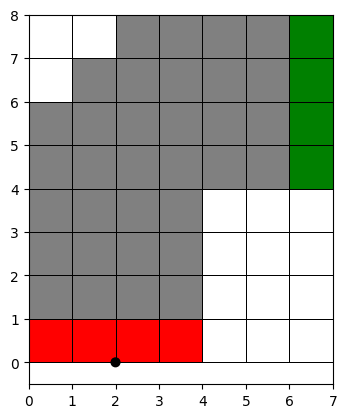

Before printing


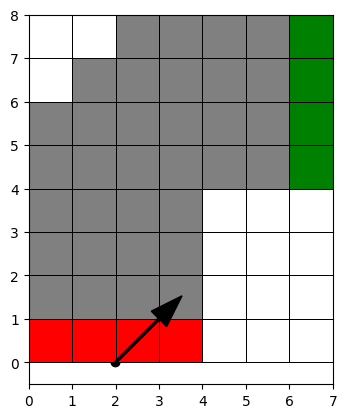

Before printing


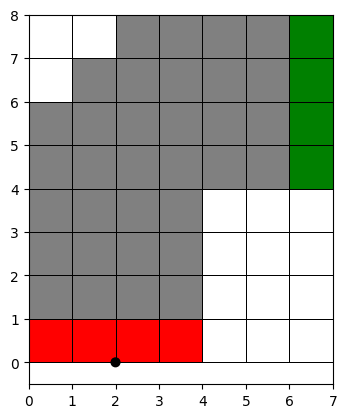

Before printing


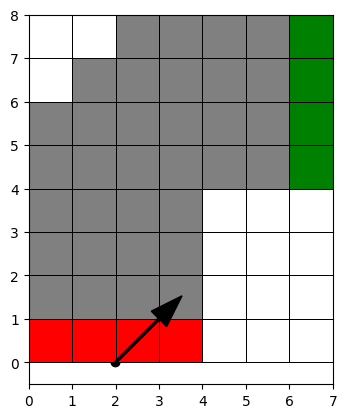

Before printing


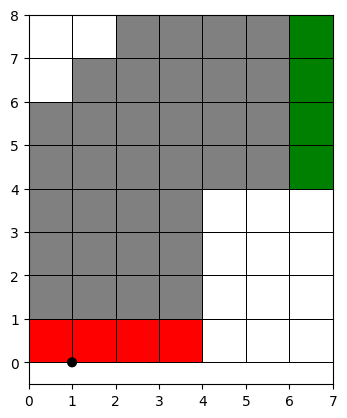

Before printing


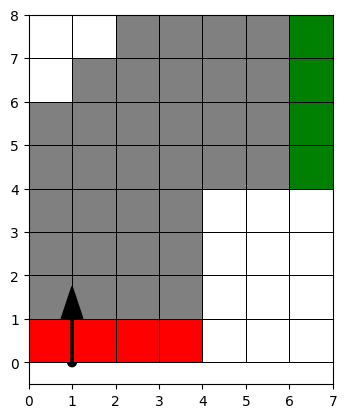

Before printing


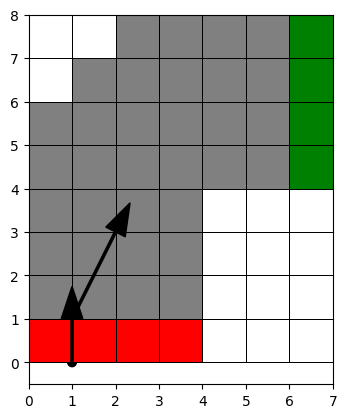

Before printing


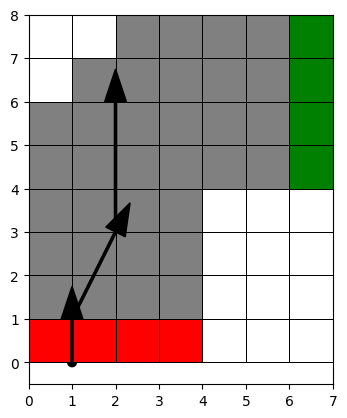

Before printing


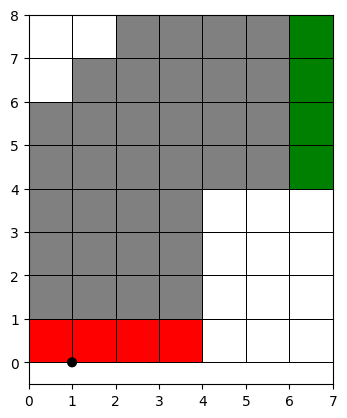

Before printing


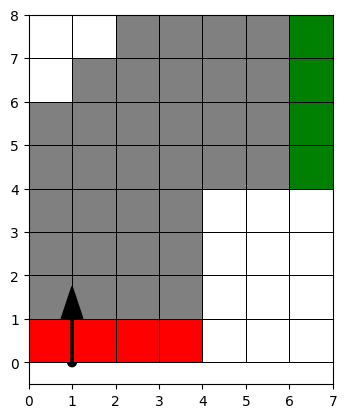

Before printing


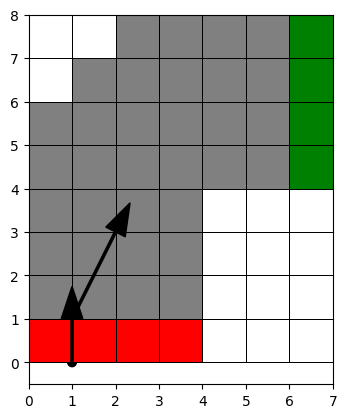

Before printing


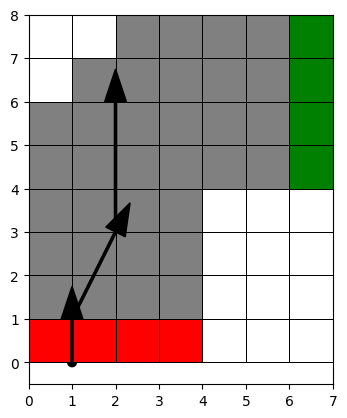

Before printing


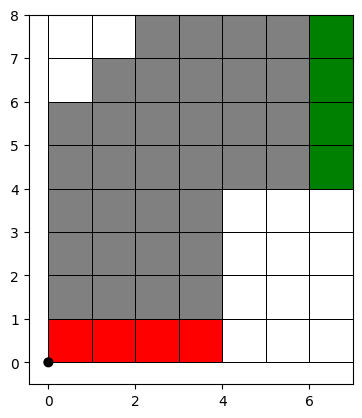

[((0, 1, 0, 0), array([2, 0]), -1.0),
 ((1, 1, 1, 0), array([2, 2]), -1.0),
 ((3, 2, 2, 1), array([2, 0]), -1.0),
 ((6, 2, 3, 0), array([2, 1]), -1.0),
 ((0, 1, 0, 0), array([2, 0]), -1.0),
 ((1, 1, 1, 0), array([2, 2]), -1.0),
 ((3, 2, 2, 1), array([2, 0]), -1.0),
 ((6, 2, 3, 0), array([2, 1]), -1.0),
 ((0, 2, 0, 0), array([2, 2]), -1.0),
 ((1, 3, 1, 1), array([2, 2]), -1.0),
 ((0, 2, 0, 0), array([2, 2]), -1.0),
 ((1, 3, 1, 1), array([2, 2]), -1.0),
 ((0, 1, 0, 0), array([2, 0]), -1.0),
 ((1, 1, 1, 0), array([2, 2]), -1.0),
 ((3, 2, 2, 1), array([2, 0]), -1.0),
 ((6, 2, 3, 0), array([2, 1]), -1.0),
 ((0, 1, 0, 0), array([2, 0]), -1.0),
 ((1, 1, 1, 0), array([2, 2]), -1.0),
 ((3, 2, 2, 1), array([2, 0]), -1.0),
 ((6, 2, 3, 0), array([2, 1]), -1.0)]

In [21]:
sample_episode(env, pi, True, render=True)

It kind of works after 1_000_000 episodes, but it is pretty slow and as you can see in the results in not always finds the best path. I guess that I made some mistakes in the implementation or something like that.

In [22]:
env_left = RacetrackEnv('racetrack_left.txt', noisy=False)
pi_eps_soft_left, pi_left, q_left = on_policy_mc_control_eps_soft(env_left, gamma=0.9, n_episodes=1_000_000)

100%|██████████| 1000000/1000000 [5:00:35<00:00, 55.45it/s]  


Before printing


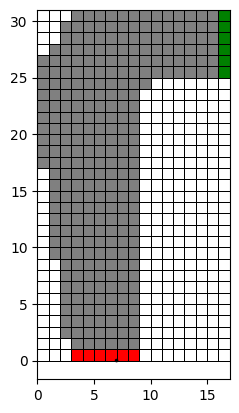

Before printing


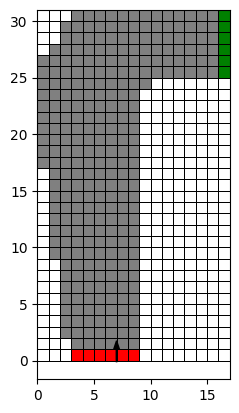

Before printing


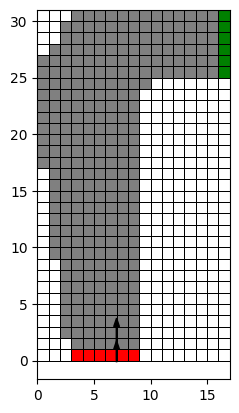

Before printing


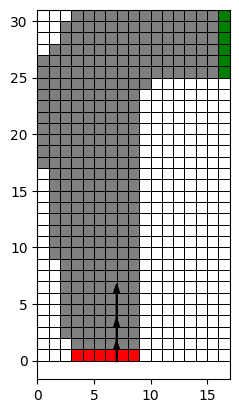

Before printing


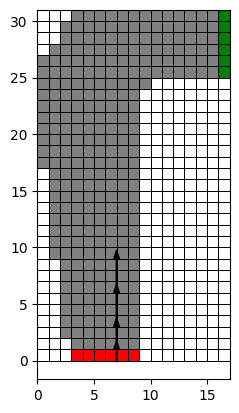

Before printing


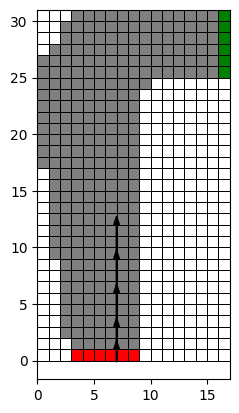

Before printing


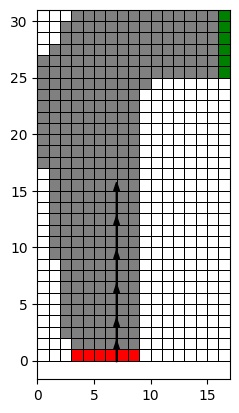

Before printing


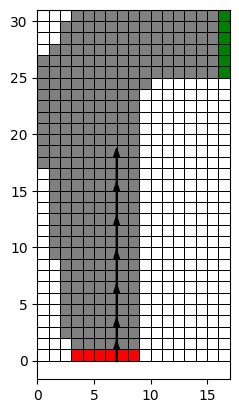

Before printing


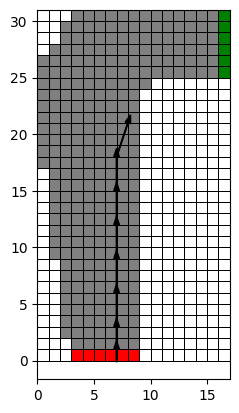

Before printing


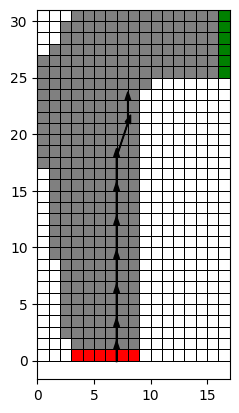

Before printing


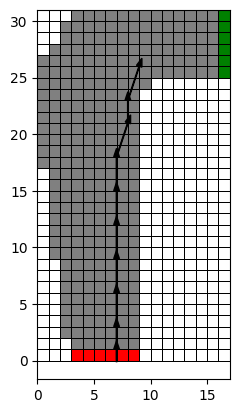

Before printing


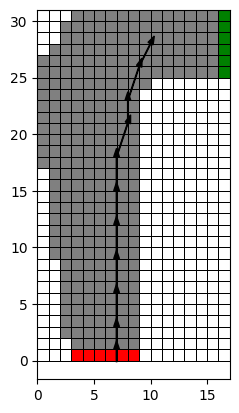

Before printing


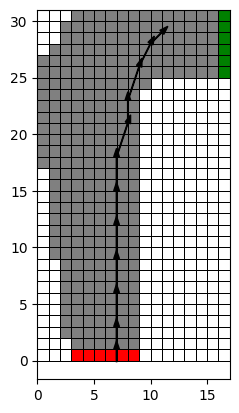

Before printing


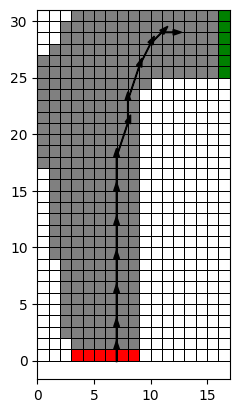

Before printing


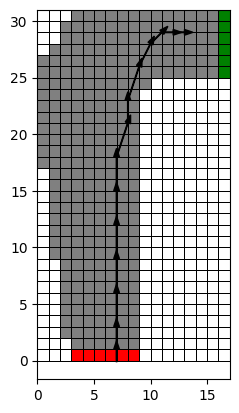

Before printing


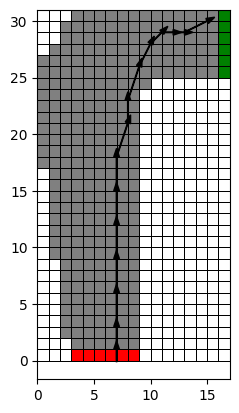

Before printing


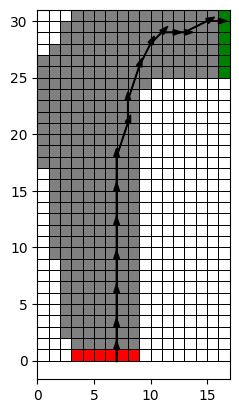

[((0, 7, 0, 0), array([2, 0]), -1.0),
 ((1, 7, 1, 0), array([2, 1]), -1.0),
 ((3, 7, 2, 0), array([2, 1]), -1.0),
 ((6, 7, 3, 0), array([1, 0]), -1.0),
 ((9, 7, 3, 0), array([1, 0]), -1.0),
 ((12, 7, 3, 0), array([1, 0]), -1.0),
 ((15, 7, 3, 0), array([1, 0]), -1.0),
 ((18, 7, 3, 0), array([1, 2]), -1.0),
 ((21, 8, 3, 1), array([0, 0]), -1.0),
 ((23, 8, 2, 0), array([2, 2]), -1.0),
 ((26, 9, 3, 1), array([0, 1]), -1.0),
 ((28, 10, 2, 1), array([0, 1]), -1.0),
 ((29, 11, 1, 1), array([0, 0]), -1.0),
 ((29, 12, 0, 1), array([0, 1]), -1.0),
 ((29, 13, 0, 1), array([2, 2]), -1.0),
 ((30, 15, 1, 2), array([0, 0]), -1.0)]

In [25]:
sample_episode(env_left, pi_left, True, render=True)

Before printing


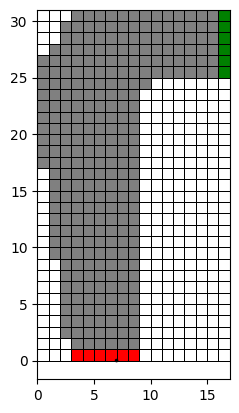

Before printing


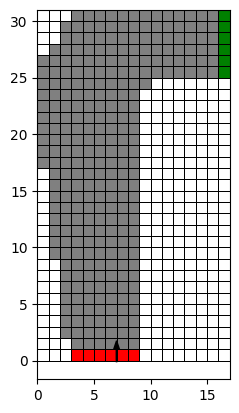

Before printing


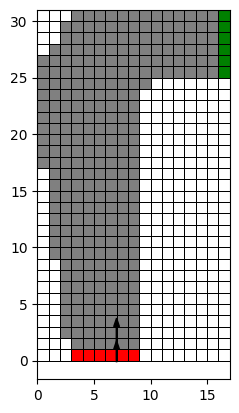

Before printing


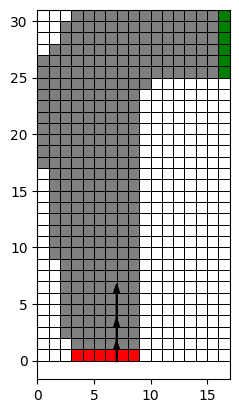

Before printing


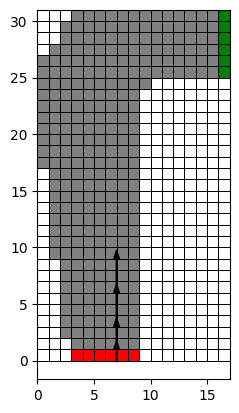

Before printing


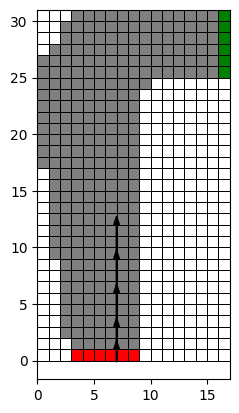

Before printing


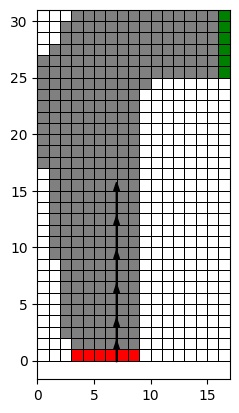

Before printing


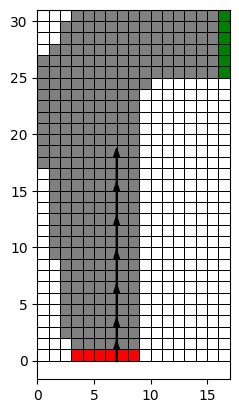

Before printing


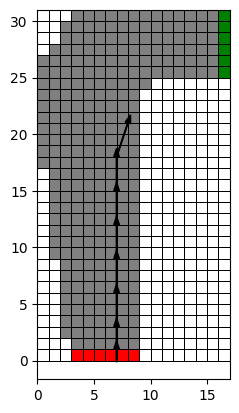

Before printing


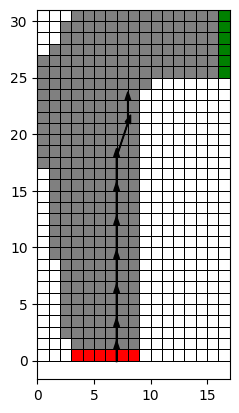

Before printing


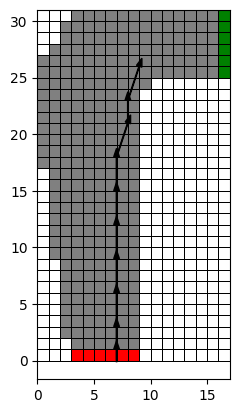

Before printing


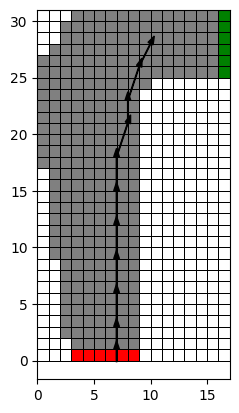

Before printing


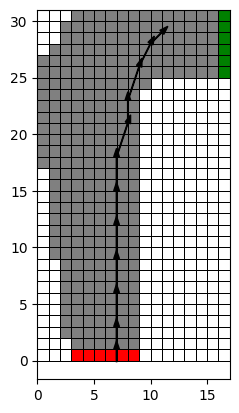

Before printing


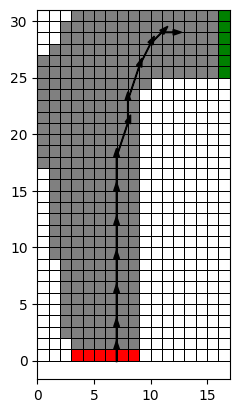

Before printing


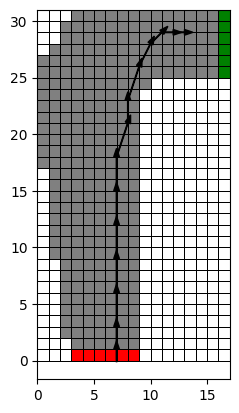

Before printing


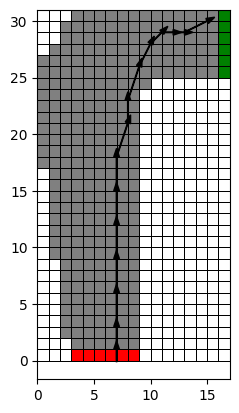

Before printing


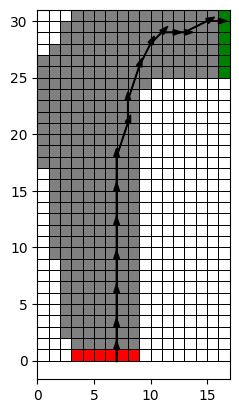

[((0, 7, 0, 0), array([2, 0]), -1.0),
 ((1, 7, 1, 0), array([2, 1]), -1.0),
 ((3, 7, 2, 0), array([2, 1]), -1.0),
 ((6, 7, 3, 0), array([1, 0]), -1.0),
 ((9, 7, 3, 0), array([1, 0]), -1.0),
 ((12, 7, 3, 0), array([1, 0]), -1.0),
 ((15, 7, 3, 0), array([1, 0]), -1.0),
 ((18, 7, 3, 0), array([1, 2]), -1.0),
 ((21, 8, 3, 1), array([0, 0]), -1.0),
 ((23, 8, 2, 0), array([2, 2]), -1.0),
 ((26, 9, 3, 1), array([0, 1]), -1.0),
 ((28, 10, 2, 1), array([0, 1]), -1.0),
 ((29, 11, 1, 1), array([0, 0]), -1.0),
 ((29, 12, 0, 1), array([0, 1]), -1.0),
 ((29, 13, 0, 1), array([2, 2]), -1.0),
 ((30, 15, 1, 2), array([0, 0]), -1.0)]

In [28]:
sample_episode(env_left, pi_left, True, render=True)

In [24]:
def off_policy_mc_control(env, gamma = 1, eps=0.1, episodes=2):
    # Each state can take up 9 actions
    n_actions = 9

    # Target policy
    pi = defaultdict(lambda: np.zeros(env.action_space.shape, dtype=int))

    Q = defaultdict(lambda: np.zeros((3, 3))) 
    C = defaultdict(lambda: np.zeros((3, 3)))

    for _ in tqdm(range(episodes)):
        episode = sample_episode(env, pi, render=False)

        G = 0
        W = 1

        t = len(episode)-1
        while t >=0 and W != 0:
            s_t, a_t, r_t = episode[t]
            
            s_t = tuple(s_t)
            a_t = tuple(a_t)

            G = gamma*G + r_t
            C[s_t][a_t[0]][a_t[1]] += W
            Q[s_t][a_t[0]][a_t[1]] += (W/C[s_t][a_t[0]][a_t[1]]) * (G - Q[s_t][a_t[0]][a_t[1]])
            
            flat_idx = np.argmax(Q[s_t])
            pi[s_t] = np.array(np.unravel_index(flat_idx, Q[s_t].shape))
            
            if a_t != tuple(pi[s_t]):
                break
            
            # Since it is the best action, that one has a fixed probability
            b_prob = (1 - eps) + (eps / n_actions)
            W = W*(1/b_prob)

            t -= 1
    
    return (pi, Q)

## References

Sutton